In [160]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

weight = 0.7
bias = 0.3

start = 0.0
end = 1.0
steps = 0.02

X = torch.arange(start, end, steps).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [161]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [162]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [163]:
def plot_pred(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b', s=4, label='training data')
  plt.scatter(test_data, test_labels, c='g', s=4, label='testing data')
  if predictions is not None:
    plt.scatter(test_data, predictions, c='r', s=4, label='predictions')
  plt.legend(prop={"size": 14})

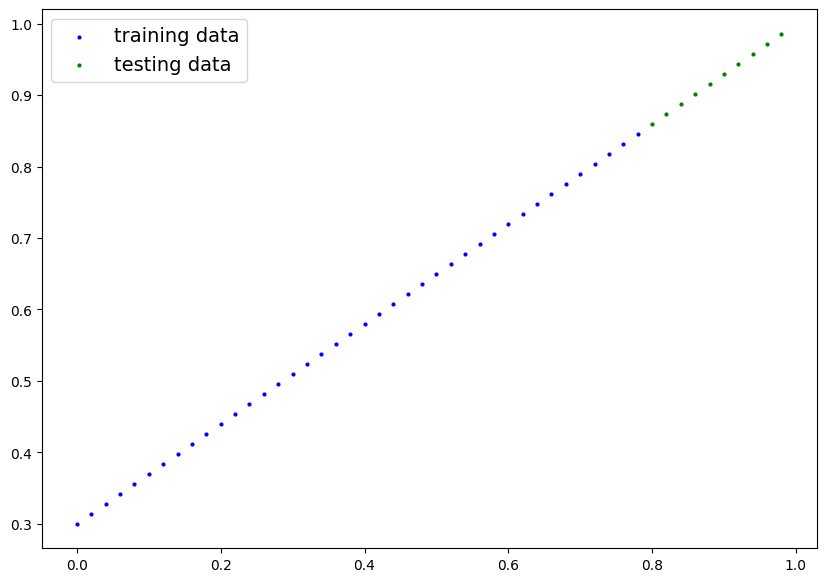

In [164]:
plot_pred()

In [165]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model1 = LinearRegressionModelV2()
model1, model1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [166]:
next(model1.parameters()).device

device(type='cpu')

In [167]:
model1.to(device)
next(model1.parameters()).device

device(type='cuda', index=0)

In [168]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.01)

In [169]:
torch.manual_seed(42)
epochs = 1000

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model1.train()
  y_pred = model1(X_train)
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model1.eval()

  with torch.inference_mode():
    test_pred = model1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779270172119 | Test loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399681091308594 | Test loss: 0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test loss: 0.16984669864177704
Epoch: 40 | Loss: 0.09433844685554504 | Test loss: 0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test loss: 0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test loss: 0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test loss: 0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test loss: 0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test loss: 0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test loss: 0.01380180101841

In [170]:
from pprint import pprint

print("The model learned the following values for weights and bias:")
print(model1.state_dict())
print("\nAnd the original values for weights and bias were:")
print(f"weight: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'linear_layer.weight': tensor([[0.6968]], device='cuda:0'), 'linear_layer.bias': tensor([0.3025], device='cuda:0')})

And the original values for weights and bias were:
weight: 0.7, bias: 0.3


In [171]:
model1.eval()
with torch.inference_mode():
  y_preds = model1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

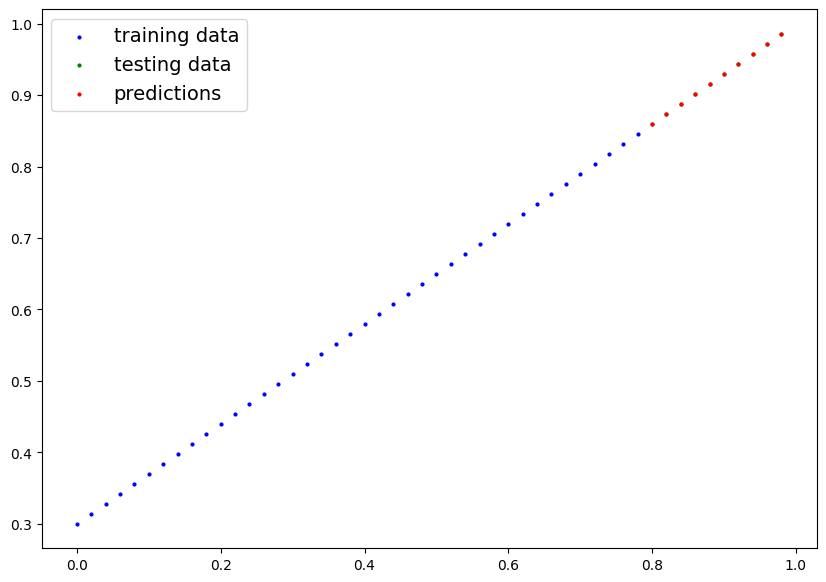

In [172]:
plot_pred(predictions=y_preds.cpu())

In [173]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model1.state_dict(),f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [174]:
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [175]:
loaded_model_1.eval()

with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

Another Pipeline of NN

In [176]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [177]:
df.shape

(569, 33)

In [178]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [179]:
X1_train, X1_test, y1_train, y1_test = train_test_split(df.iloc[:, 1:], df.iloc[:,0], test_size=0.2)

scaler = StandardScaler()
X1_train = scaler.fit_transform(X1_train)
X1_test = scaler.transform(X1_test)

In [180]:
encoder = LabelEncoder()
y1_train = encoder.fit_transform(y1_train)
y1_test

,diagnosis
218,M
484,B
125,B
173,B
554,B
...,...
86,M
206,B
284,B
438,B


In [181]:
y1_test_encoded = encoder.transform(y1_test)

X_train_tensor = torch.from_numpy(X1_train).float()
X_test_tensor = torch.from_numpy(X1_test).float()
y_train_tensor = torch.from_numpy(y1_train).float()
y_test_tensor = torch.from_numpy(y1_test_encoded).float()

X_train_tensor.shape, y_train_tensor.shape

(torch.Size([455, 30]), torch.Size([455]))

In [182]:
class SimpleNN(nn.Module):
  def __init__(self, in_features):
    super().__init__()

    self.weight = nn.Parameter(torch.rand(in_features, 1))
    self.bias = nn.Parameter(torch.rand(1))
  def forward(self, x):
    z = torch.matmul(x, self.weight) + self.bias
    return torch.sigmoid(z)

In [183]:
model2 = SimpleNN(in_features=30).to(device)

In [184]:
loss_fn2 = nn.BCELoss()
optimizer_2 = torch.optim.SGD(params=model2.parameters(), lr=0.01)

In [185]:
torch.manual_seed(42)
epochs = 100

# Ensure data is on the correct device and has the correct shape
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device).unsqueeze(dim=1)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device).unsqueeze(dim=1)

for epoch in range(epochs):
  model2.train()
  # 1. Forward pass
  y_pred = model2(X_train_tensor)

  # 2. Calculate loss
  loss = loss_fn2(y_pred, y_train_tensor)

  # 3. Optimizer zero grad
  optimizer_2.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer_2.step()

  # Testing
  if epoch % 10 == 0:
    model2.eval()
    with torch.inference_mode():
      test_pred = model2(X_test_tensor)
      test_loss = loss_fn2(test_pred, y_test_tensor)
      print(f"Epoch: {epoch} | Train loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.79380 | Test loss: 0.57991
Epoch: 10 | Train loss: 0.77926 | Test loss: 0.55885
Epoch: 20 | Train loss: 0.76514 | Test loss: 0.53858
Epoch: 30 | Train loss: 0.74989 | Test loss: 0.51908
Epoch: 40 | Train loss: 0.73569 | Test loss: 0.50032
Epoch: 50 | Train loss: 0.72210 | Test loss: 0.48228
Epoch: 60 | Train loss: 0.70900 | Test loss: 0.46494
Epoch: 70 | Train loss: 0.69600 | Test loss: 0.44828
Epoch: 80 | Train loss: 0.68328 | Test loss: 0.43228
Epoch: 90 | Train loss: 0.67110 | Test loss: 0.41690


In [186]:
with torch.inference_mode():
  y_pred = model2.forward(X_test_tensor)
  y_pred = (y_pred > 0.9).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')


Accuracy: 0.8771929740905762


# **Third NN Pipeline**

In [187]:
weight1 = 0.3
bias1 = 0.9

start = 0.0
end = 1.0
steps = 0.02

X = torch.arange(start, end, steps).unsqueeze(dim=1)
y = weight1 * X + bias1
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.9000],
         [0.9060],
         [0.9120],
         [0.9180],
         [0.9240],
         [0.9300],
         [0.9360],
         [0.9420],
         [0.9480],
         [0.9540]]))

In [188]:
device1 = "cuda" if torch.cuda.is_available() else "cpu"
device1

'cuda'

In [189]:
train_split = int(0.8 * len(X))
X2_train, y2_train = X[:train_split], y[:train_split]
X2_test, y2_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

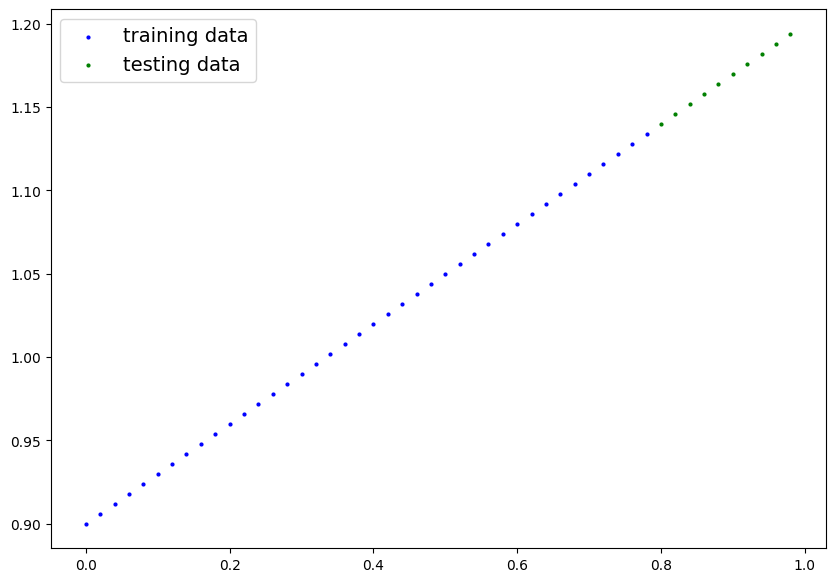

In [190]:
plot_pred(X2_train, y2_train, X2_test, y2_test)

In [191]:
class LinearRegressionModelV3(nn.Module):
  def __init__(self):
    super().__init__()

    self.weight1 = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
    self.bias1 = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
     return self.weight1 * x + self.bias1

torch.manual_seed(42)
model3 = LinearRegressionModelV3()
model3, model3.state_dict()

(LinearRegressionModelV3(),
 OrderedDict([('weight1', tensor([0.3367])), ('bias1', tensor([0.1288]))]))

In [192]:
next(model3.parameters()).device

device(type='cpu')

In [193]:
model3.to(device)
next(model3.parameters()).device

device(type='cuda', index=0)

In [194]:
loss_fn3 = nn.L1Loss()
optimizer_3 = torch.optim.SGD(params=model3.parameters(), lr=0.01)

In [195]:
torch.manual_seed(42)
epochs = 300

# Ensure all data is on the same device as the model
X2_train = X2_train.to(device)
y2_train = y2_train.to(device)
X2_test = X2_test.to(device)
y2_test = y2_test.to(device)

for epoch in range(epochs):
  model3.train()
  # 1. Forward pass
  y_pred2 = model3(X2_train)

  # 2. Calculate loss (comparing predictions to actual training labels)
  loss = loss_fn3(y_pred2, y2_train)

  # 3. Optimizer zero grad
  optimizer_3.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer_3.step()

  if epoch % 20 == 0:
    model3.eval()
    with torch.inference_mode():
      test_pred = model3(X2_test)
      test_loss = loss_fn3(test_pred, y2_test)
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75688 | Test loss: 0.72507
Epoch: 20 | Loss: 0.52646 | Test loss: 0.45565
Epoch: 40 | Loss: 0.29604 | Test loss: 0.18623
Epoch: 60 | Loss: 0.07731 | Test loss: 0.06994
Epoch: 80 | Loss: 0.05213 | Test loss: 0.11545
Epoch: 100 | Loss: 0.04510 | Test loss: 0.10440
Epoch: 120 | Loss: 0.03823 | Test loss: 0.08854
Epoch: 140 | Loss: 0.03136 | Test loss: 0.07268
Epoch: 160 | Loss: 0.02449 | Test loss: 0.05682
Epoch: 180 | Loss: 0.01762 | Test loss: 0.04028
Epoch: 200 | Loss: 0.01076 | Test loss: 0.02442
Epoch: 220 | Loss: 0.00389 | Test loss: 0.00856
Epoch: 240 | Loss: 0.00755 | Test loss: 0.00866
Epoch: 260 | Loss: 0.00755 | Test loss: 0.00866
Epoch: 280 | Loss: 0.00755 | Test loss: 0.00866


In [196]:
print("The model learned the following values for weights and bias:")
print(model3.state_dict())
print("\nAnd the original values for weights and bias were:")
print(f"weight: {weight1}, bias: {bias1}")

The model learned the following values for weights and bias:
OrderedDict({'weight1': tensor([0.3055], device='cuda:0'), 'bias1': tensor([0.8903], device='cuda:0')})

And the original values for weights and bias were:
weight: 0.3, bias: 0.9


In [197]:
model3.eval()

# Ensure X2_test is on the same device as model3
X2_test = X2_test.to(device)

with torch.inference_mode():
  y_preds_3 = model3(X2_test)

y_preds_3

tensor([[1.1347],
        [1.1408],
        [1.1469],
        [1.1530],
        [1.1591],
        [1.1652],
        [1.1714],
        [1.1775],
        [1.1836],
        [1.1897]], device='cuda:0')

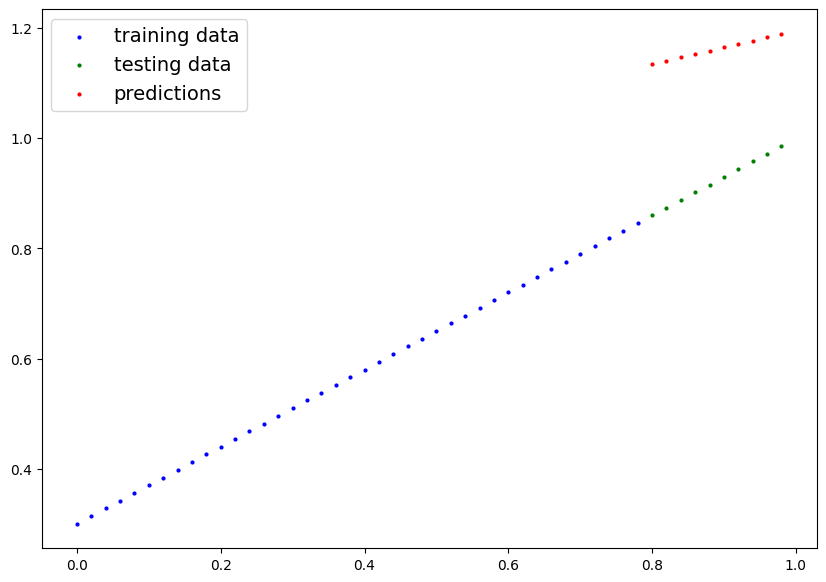

In [198]:
plot_pred(predictions=y_preds_3.cpu())

In [203]:
from pathlib import Path

MODEL_PATH = Path('model')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'model.h5'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"save to {MODEL_SAVE_PATH}")
torch.save(obj=model3.state_dict(), f=MODEL_SAVE_PATH)

save to model/model.h5


In [200]:
loaded_model_3 = LinearRegressionModelV3()
loaded_model_3.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_3.to(device)

print(f"Loaded model:\n{loaded_model_3}")
print(f"Model on device:\n{next(loaded_model_3.parameters()).device}")

Loaded model:
LinearRegressionModelV3()
Model on device:
cuda:0


In [204]:
loaded_model_3.eval()

with torch.inference_mode():
  loaded_model_3_preds = loaded_model_3(X2_test)
y_preds_3 == loaded_model_3_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')